In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)
data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan

data["order_value"][5] = 95000
data["order_value"][88] = 87000

df = pd.DataFrame(data)
print(df.shape)
df.head()


(200, 6)


,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1


#Task 1 — Inspect & Handle Missing Values

In [2]:
#Print the shape of the DataFrame (number of rows and columns).
print(f"Shape of the DataFrame (number of rows and columns) {df.shape}")
#Display the data types of all columns.
print(f"\nData types of all columns\n{df.dtypes}")
#Check for missing values in each column.
#Count the number of missing values in each column.
print(f"\nMissing values in each column \n{df.isnull().sum()}")
#Calculate the percentage of missing values for each column, rounded to 2 decimal places.
#print(f"\nPercentage of missing values for each column \n{round(df.isnull().mean()*100,2)}")
print(f"\nPercentage of missing values for each column \n{round(df.isnull().sum()/len(df)*100,2)}")
#Hint: Percentage = (missing count / total rows) * 100

Shape of the DataFrame (number of rows and columns) (200, 6)

Data types of all columns
order_id           int64
city              object
category          object
order_value      float64
delivery_days    float64
rating            object
dtype: object

Missing values in each column 
order_id          0
city              0
category          0
order_value      14
delivery_days    10
rating           32
dtype: int64

Percentage of missing values for each column 
order_id          0.0
city              0.0
category          0.0
order_value       7.0
delivery_days     5.0
rating           16.0
dtype: float64


#Task 2 — Summarize & Visualize

          order_id   order_value  delivery_days
count   200.000000    186.000000     190.000000
mean   1100.500000   3707.134409       7.810526
std      57.879185   9238.438378       4.075465
min    1001.000000    204.000000       1.000000
25%    1050.750000   1512.000000       4.000000
50%    1100.500000   2934.000000       8.000000
75%    1150.250000   3987.500000      12.000000
max    1200.000000  95000.000000      14.000000


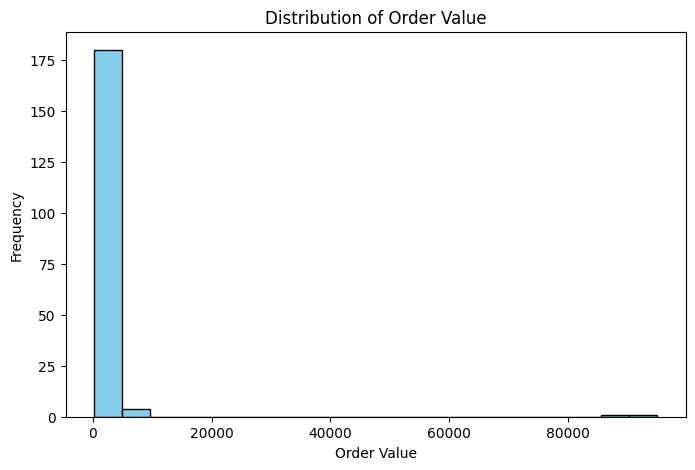

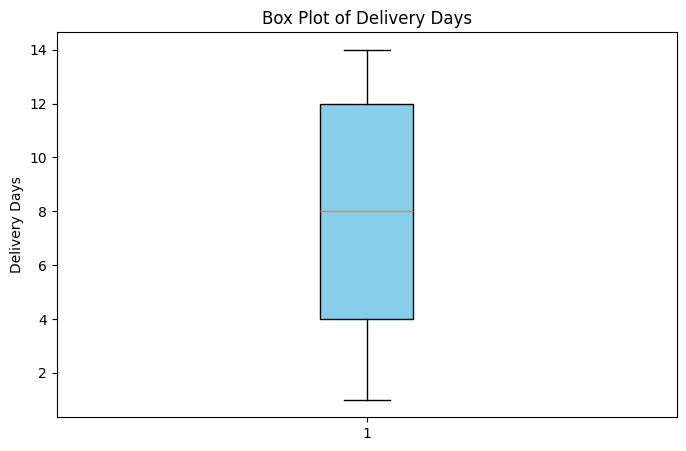

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
#Use df.describe() to generate a summary of all numerical columns.
summary = df.describe()
print(summary)
#Plot a histogram for the order_value column to visualize its distribution.
#Make sure every plot has a title and axis labels.
plt.figure(figsize=(8, 5))
plt.hist(df['order_value'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.show()
#Plot a box plot for the delivery_days column to inspect for outliers.
#Make sure every plot has a title and axis labels.
plt.figure(figsize=(8, 5))
plt.boxplot(df['delivery_days'].dropna(), patch_artist=True,
            boxprops=dict(facecolor='skyblue', color='black'))
plt.title("Box Plot of Delivery Days")
plt.ylabel("Delivery Days")
plt.show()




#Observations from the summary (for example: which column has the highest mean, or which column shows a large gap between its max and 75th percentile).
order_value is having the highest mean compared to median, large gap(outliers) are found in order_value column compared to the max value to the 75% or 50% percentile, which will result in right skewed distribution.
Histogram on order_value makes this skew visible, with most values clustered below 5000 but a few extreme spikes far to the right.
Box plot for delivery_days shows a fairly even spread, with some higher values that could be less common occurence.

#Task 3 — Correlation Analysis

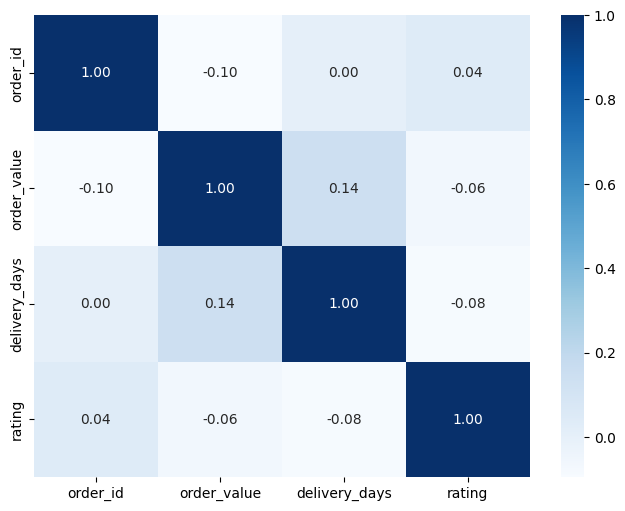

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

#Compute the correlation matrix for all numerical columns using df.corr()
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()
#Plot a heatmap of the correlation matrix with annotation values visible inside each cell.
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot= True, cmap="Blues", fmt=".2f")
plt.show()

#identify any two columns that appear to have a notable positive or negative relationship.
order_value and delivery_days show a slight positive correlation, i.e.larger orders may take a bit longer to deliver.
Whereas, rating has very weak correlations with both order_value and delivery_days, indicating that customer satisfaction scores are not strongly tied to order value or delivery time from the data given